In [21]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from scipy.special import softmax
from sklearn.metrics import balanced_accuracy_score, accuracy_score, roc_auc_score

from src.utils.analysis_utils import (
    get_summary_df,
    get_slopes_df,
    plot_slope,
    plot_metric_bars,
    plot_distance_slope,
    plot_distance_generalisation,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Config

In [14]:
RESULTS_DIR = 'processed_results'
os.makedirs(os.path.join(RESULTS_DIR, 'siglip_peft'), exist_ok=True)

label = 'Pleural_Effusion'
model = 'SigLIP-PEFT'
dataset = 'SigLIP-PEFT'

experiment_string = 'siglip_peft_alloc'
required_lr = 5e-5
required_data_name = 'MIMIC'

attributes = [
    'ViewPosition_binary',
    'Gender_binary',
    'Race_cat_binary',
    'Age_binary',
    'Marital_Status_binary',
    'Support_Devices_binary',
    'Random_binary',
    'PerformedProcedureStepDescription_binary',
]

test_metadata_df = pd.read_csv('data/MIMIC/Pleural_Effusion/test_labels.csv.gz')
test_metadata_df['id'] = test_metadata_df['dicom_id']

# Pre-computed distances from the pre-trained FM feature space (reused from fm_analysis)
emd_df = pd.read_csv(os.path.join(RESULTS_DIR,
    'fmmimic/pretrain_mean_distances_correct_pcs_stds_reduced_mmdfd.csv'))
emd_df = emd_df.rename(columns={'Unnamed: 0': 'subgroup'})

In [3]:
all_runs_df, summary_df = get_summary_df(
    experiment_string, test_metadata_df, required_lr, required_data_name, attributes
)

Skipping: logs/siglip_peft_alloc_ViewPosition_binary_20/runs/2026-04-04_15-46-21-760137/preds.csv
Skipping: logs/siglip_peft_alloc_ViewPosition_binary_20/runs/2026-04-04_15-48-32-286480/preds.csv
Skipping: logs/siglip_peft_alloc_ViewPosition_binary_20/runs/2026-04-04_15-46-21-759852/preds.csv
Skipping: logs/siglip_peft_alloc_Gender_binary_30/runs/2026-04-04_16-11-18-341405/preds.csv
Skipping: logs/siglip_peft_alloc_Age_binary_20/runs/2026-04-04_13-26-24-480654/preds.csv
Skipping: logs/siglip_peft_alloc_PerformedProcedureStepDescription_binary_20/runs/2026-04-04_14-02-12-215505/preds.csv
Skipping: logs/siglip_peft_alloc_PerformedProcedureStepDescription_binary_20/runs/2026-04-04_15-44-30-000062/preds.csv
Skipping: logs/siglip_peft_alloc_PerformedProcedureStepDescription_binary_20/runs/2026-04-04_15-40-17-272746/preds.csv


# Subgroup alloc

/gpfs3/well/papiez/users/hri611/python/data-centric-bias/src/utils/analysis_utils.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subgroup_df.sort_values(by='proportion', inplace=True)


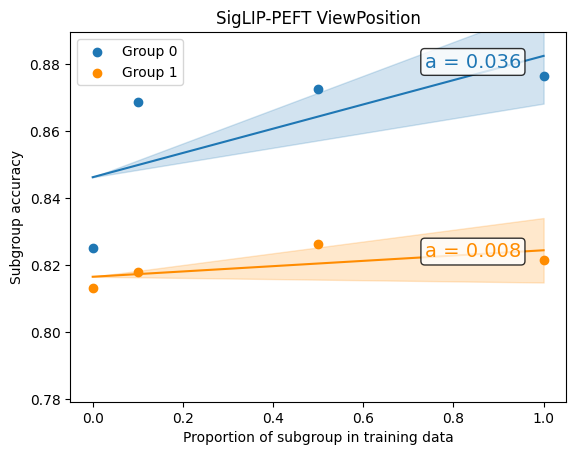

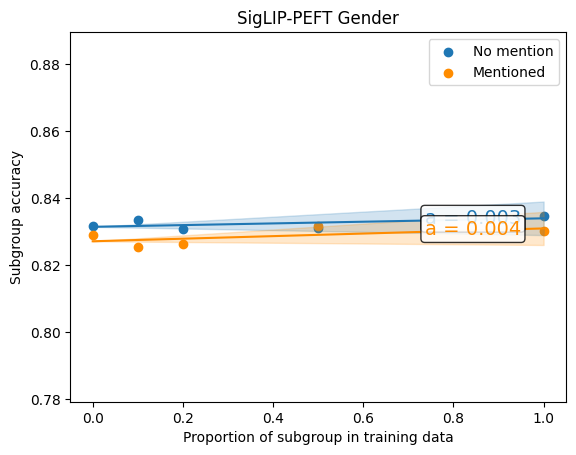

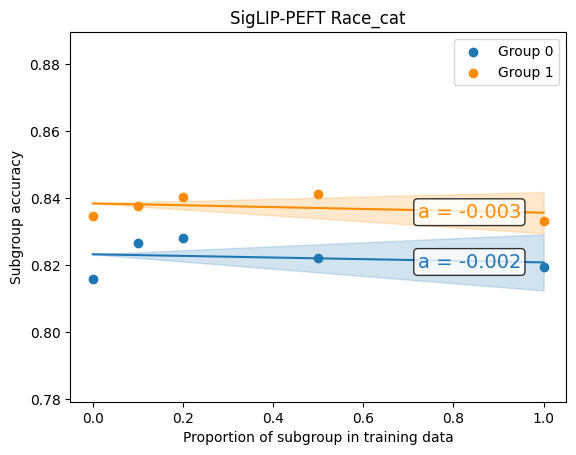

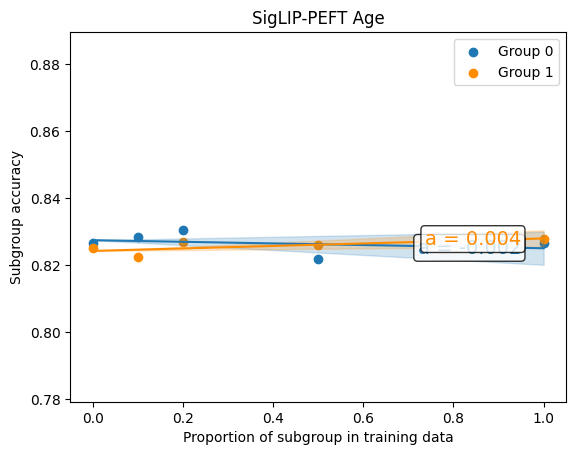

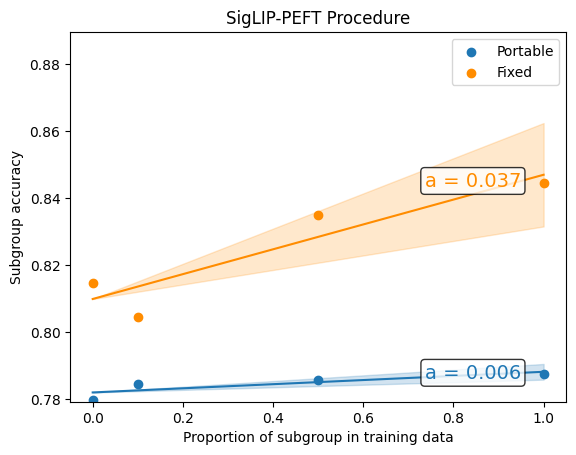

In [4]:
metric = 'balanced_acc'

min_val = min(all_runs_df[metric+'_group_0'].min(), all_runs_df[metric+'_group_1'].min())
max_val = max(all_runs_df[metric+'_group_0'].max(), all_runs_df[metric+'_group_1'].max())

filtered_df = all_runs_df.copy()

plot_slope(filtered_df, summary_df, metric, min_val, max_val, dataset)

In [5]:
metrics = ['auc', 'balanced_acc', 'loss']
subgroups = all_runs_df['subgroup'].unique()

rows = []

for subgroup in subgroups:
    subgroup_df = all_runs_df[all_runs_df['subgroup'] == subgroup]

    row = {'subgroup': subgroup}

    for metric in metrics:
        for prop in [0, 50, 100]:
            prop_df = subgroup_df[subgroup_df['proportion'] == prop]

            g0_vals = prop_df[f'{metric}_group_0'].dropna().values
            g1_vals = prop_df[f'{metric}_group_1'].dropna().values

            row[f'{metric}_group_0_mean_at_{prop}'] = np.mean(g0_vals) if len(g0_vals) > 0 else np.nan
            row[f'{metric}_group_1_mean_at_{prop}'] = np.mean(g1_vals) if len(g1_vals) > 0 else np.nan
            row[f'{metric}_group_0_std_at_{prop}'] = (np.std(g0_vals, ddof=1)) / np.sqrt(3) if len(g0_vals) > 1 else np.nan
            row[f'{metric}_group_1_std_at_{prop}'] = (np.std(g1_vals, ddof=1)) / np.sqrt(3) if len(g1_vals) > 1 else np.nan

            both_vals = np.concatenate([g0_vals, g1_vals])
            row[f'{metric}_mean_at_{prop}'] = np.mean(both_vals) if len(both_vals) > 0 else np.nan
            row[f'{metric}_std_at_{prop}'] = (
                row[f'{metric}_group_0_std_at_{prop}'] + row[f'{metric}_group_1_std_at_{prop}']
            ) / 2

    rows.append(row)

summary_perf_df = pd.DataFrame(rows)
summary_perf_df['subgroup'] = summary_perf_df['subgroup'].str.replace('_binary', '', regex=False)

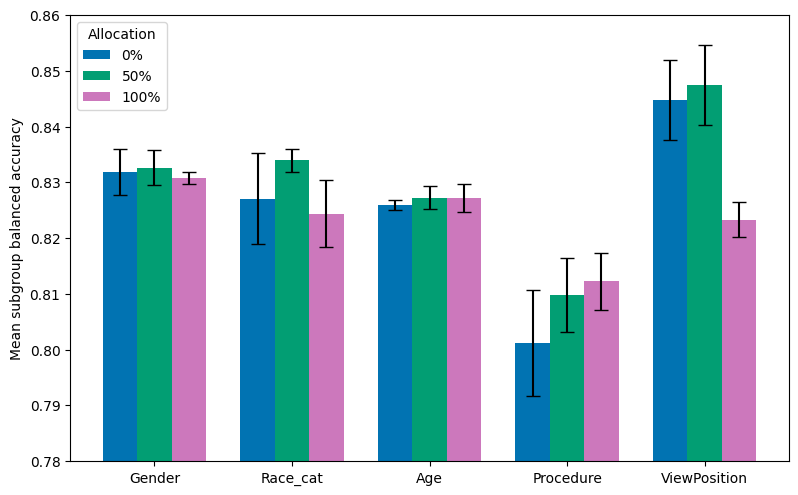

In [22]:
summary_perf_df['subgroup'] = summary_perf_df['subgroup'].replace({
    'PerformedProcedureStepDescription': 'Procedure',
})
order = ['Gender', 'Race_cat', 'Age', 'Procedure', 'ViewPosition']
subset_df = summary_perf_df[
    summary_perf_df['subgroup'].isin(order)
].copy()
subset_df['subgroup'] = pd.Categorical(
    subset_df['subgroup'],
    categories=order,
    ordered=True
)
subset_df = subset_df.sort_values('subgroup')

plot_metric_bars(subset_df, metric='balanced_acc', ylim=[0.78, 0.86])

In [10]:
metrics = ['auc', 'balanced_acc', 'loss']
subgroups = all_runs_df['subgroup'].unique()

slopes_df = get_slopes_df(filtered_df, metrics, subgroups)

# Merge with pre-trained distances

In [12]:
slopes_df

,subgroup,auc_slope_group_0,auc_slope_group_1,auc_slope_mean,auc_slope_group_0_std,auc_slope_group_1_std,auc_slope_std,auc_diff_group_0,auc_diff_group_1,auc_diff_mean,...,loss_slope_mean,loss_slope_group_0_std,loss_slope_group_1_std,loss_slope_std,loss_diff_group_0,loss_diff_group_1,loss_diff_mean,loss_diff_group_0_std,loss_diff_group_1_std,loss_diff_std
0,ViewPosition,0.002215,0.005588,0.003901,0.000239,0.000520,0.000380,0.002986,0.006241,0.004613,...,-0.011367,0.002557,0.001777,0.002167,-0.005132,-0.016962,-0.011047,0.001138,0.005302,0.003220
1,Gender,0.000259,0.000630,0.000444,0.000223,0.000167,0.000195,0.000588,0.000450,0.000519,...,-0.000823,0.000680,0.000724,0.000702,-0.002529,-0.000593,-0.001561,0.000934,0.000863,0.000899
2,Race_cat,0.000096,-0.000156,-0.000030,0.000310,0.000365,0.000338,0.000742,-0.000734,0.000004,...,-0.001250,0.001359,0.001528,0.001443,-0.000547,0.000652,0.000052,0.000738,0.001134,0.000936
3,Age,-0.000097,0.002135,0.001019,0.000135,0.000290,0.000212,0.000249,0.001859,0.001054,...,-0.001296,0.000315,0.000444,0.000379,0.001956,-0.004934,-0.001489,0.000303,0.000447,0.000375
4,PerformedProcedureStepDescription,0.006244,0.006434,0.006339,0.000814,0.000283,0.000549,0.009155,0.006771,0.007963,...,-0.017808,0.004096,0.001823,0.002959,-0.035813,-0.016389,-0.026101,0.006226,0.003902,0.005064


In [15]:
emd_df

,subgroup,WD_g0_vs_g1_mean,WD_g0_vs_g1_std,WD_g0_vs_all_mean,WD_g0_vs_all_std,WD_g1_vs_all_mean,WD_g1_vs_all_std,FD_g0_vs_g1_mean,FD_g0_vs_g1_std,FD_g0_vs_all_mean,FD_g0_vs_all_std,FD_g1_vs_all_mean,FD_g1_vs_all_std,TVD_g0_vs_g1_mean,TVD_g0_vs_g1_std,TVD_g0_vs_all_mean,TVD_g0_vs_all_std,TVD_g1_vs_all_mean,TVD_g1_vs_all_std
0,ViewPosition,1.311856,0.0,1.014520,0.0,0.297336,0.0,274.367319,0.0,0.004281,0.0,0.000250,0.0,0.228693,0.0,0.004281,0.0,0.000250,0.0
1,Gender,1.036385,0.0,0.540551,0.0,0.495834,0.0,145.682169,0.0,0.000990,0.0,0.000909,0.0,0.180716,0.0,0.000990,0.0,0.000909,0.0
2,Race_cat,0.917086,0.0,0.624461,0.0,0.292625,0.0,147.848612,0.0,0.002263,0.0,0.000408,0.0,0.184748,0.0,0.002263,0.0,0.000408,0.0
3,Age,1.083450,0.0,0.743788,0.0,0.339662,0.0,183.269890,0.0,0.002510,0.0,0.000377,0.0,0.197977,0.0,0.002510,0.0,0.000377,0.0
4,Marital_Status,0.748901,0.0,0.355991,0.0,0.392910,0.0,107.135111,0.0,0.000942,0.0,0.000969,0.0,0.168871,0.0,0.000942,0.0,0.000969,0.0
5,Support_Devices,1.275532,0.0,0.398537,0.0,0.876995,0.0,287.423636,0.0,0.000537,0.0,0.001962,0.0,0.201527,0.0,0.000537,0.0,0.001962,0.0
6,Random,0.313720,0.0,0.154199,0.0,0.159520,0.0,19.999331,0.0,0.000862,0.0,0.000945,0.0,0.138676,0.0,0.000862,0.0,0.000945,0.0
7,PerformedProcedureStepDescription,1.389359,0.0,0.628748,0.0,0.760611,0.0,374.002846,0.0,0.000712,0.0,0.001685,0.0,0.203756,0.0,0.000712,0.0,0.001685,0.0


In [16]:
slopes_df = slopes_df.merge(emd_df, on='subgroup')
slopes_df = slopes_df.rename(columns={col: col.replace('FID', 'FD') for col in slopes_df.columns if 'FID' in col})
slopes_df = slopes_df.rename(columns={col: col.replace('TVD', 'TV') for col in slopes_df.columns if 'TVD' in col})

In [17]:
slopes_df = slopes_df[slopes_df['subgroup'] != 'PatientOrientationCodeSequence_CodeMeaning']
slopes_df = slopes_df[slopes_df['subgroup'] != 'Language']

In [ ]:
slopes_df.to_csv(
    os.path.join(RESULTS_DIR, 'siglip_peft', 'slopes_df.csv'), index=False
)

# Distance vs slope plots

0.23341669610959917
0.017965568886915834
0.0016121320715616076


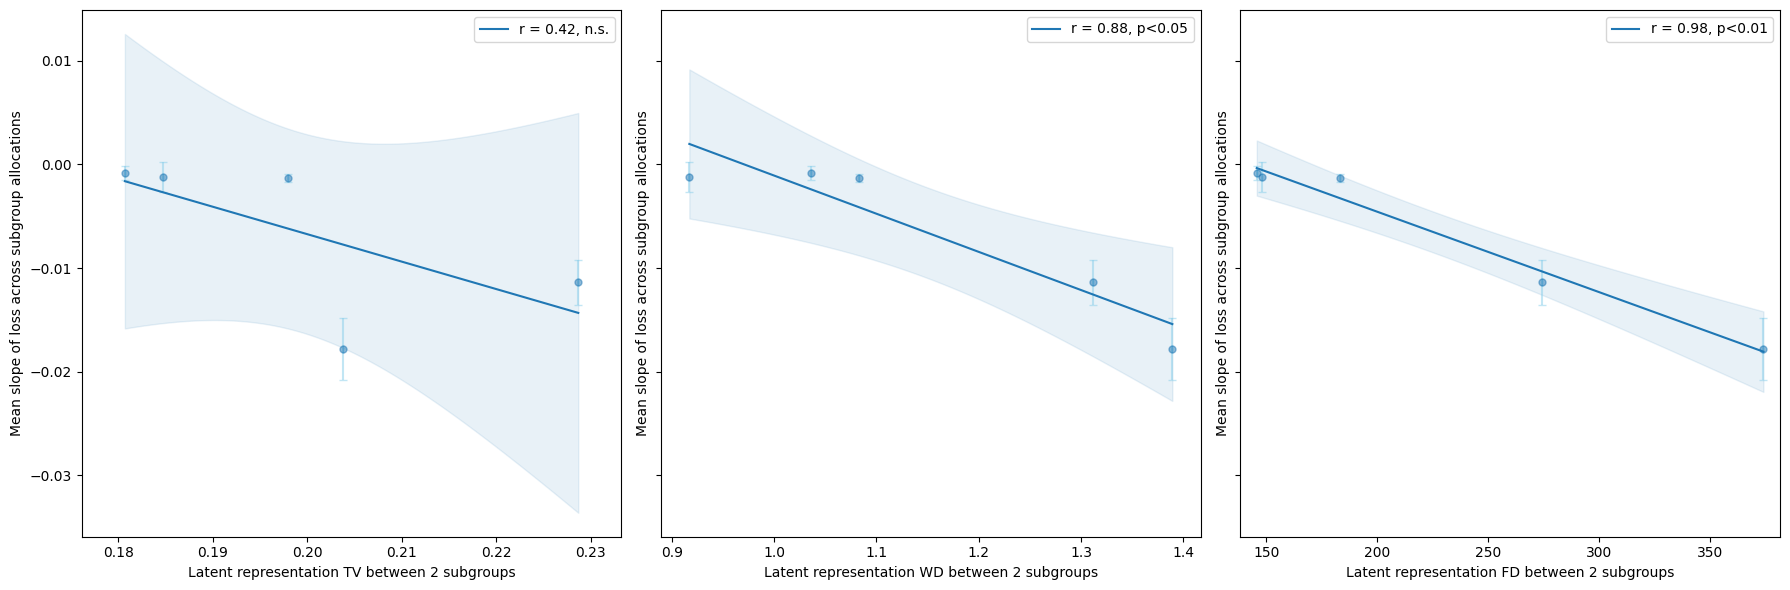

0.3947173855477829
0.03379856208395677
0.0029881718665998314


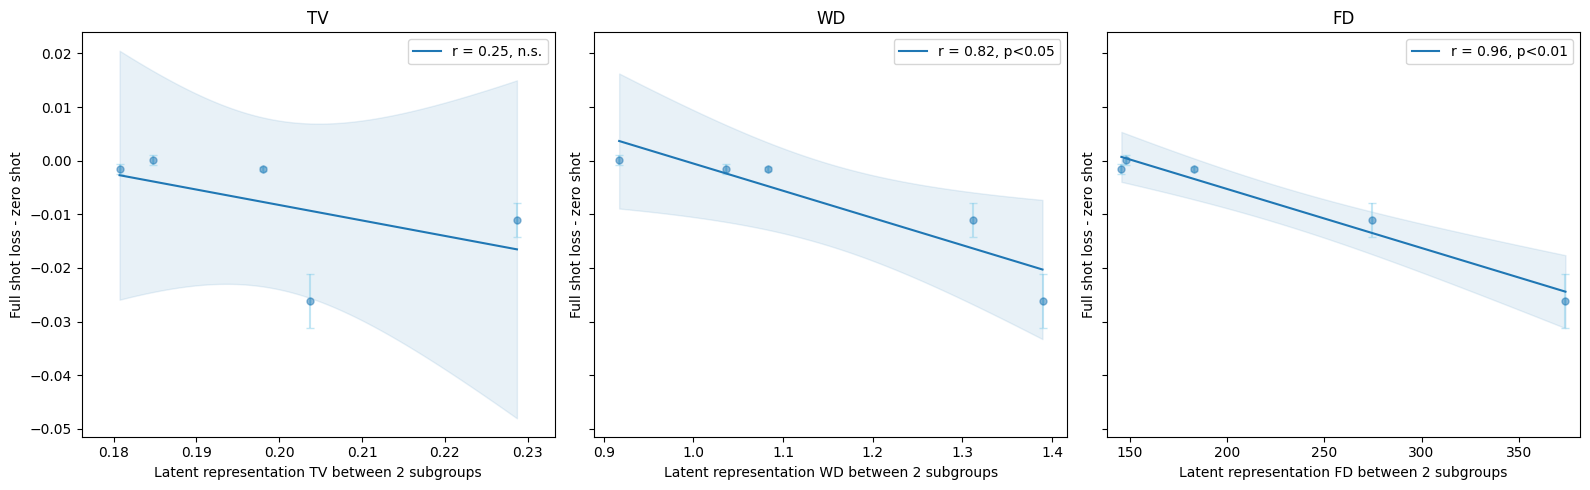

In [18]:
distance_metrics = ['TV', 'WD', 'FD']
metric = 'loss'

plot_distance_slope(slopes_df, distance_metrics, metric)
plot_distance_generalisation(slopes_df, distance_metrics, metric)

In [ ]:
metric = 'balanced_acc'

diff_col = f'{metric}_diff_mean'
std_col = f'{metric}_diff_std'

sorted_df = slopes_df.sort_values('TV_g0_vs_g1_mean')
x_pos = np.arange(len(sorted_df))
plt.figure(figsize=(8, 5))
plt.bar(x_pos, -sorted_df[diff_col], yerr=sorted_df[std_col],
        capsize=5, color='cornflowerblue', alpha=0.8, error_kw={'alpha': 0.5, 'lw': 1})
plt.ylabel(r'$\Delta$ Balanced Accuracy')
plt.tight_layout()
plt.xticks(x_pos, sorted_df['subgroup'], rotation=0)
plt.show()